<div style="display: flex; align-items: center; gap: 20px; background-color: rgba(173, 38, 191, 0.74); padding: 20px; border-radius: 10px; color: white;">
  <img src="https://gna.org.co/wp-content/uploads/2025/06/LOGO-GNA-TRANSP.png" alt="GNA logo" style="height: 120px;">
  <div>
      <h1 style="margin: 0; font-size: 2.3em; font-weight: bold;">Workshop: fMRI basics</h1>
      <p style="margin: 10px 0 5px 0; font-size: 1.3em;"><strong>Grupo de Neurociencias de Antioquia</strong></p>
      <p style="margin: 10px 0 5px 0; font-size: 1.2em;"><strong>Línea de Neurociencias Computacionales</strong> </p>
      <p style="margin: 10px 0 5px 0; font-size: 1em;">Prepared by: Keveen Rodríguez, Luisa Fernanda Taho </p>
      <p style="margin: 10px 0 5px 0; font-size: 1em;">Revised by: Johanna Roca </p>
      <p style="margin: 5px 0; font-size: 1em;">Date:26/08/26  </p>
  </div>
</div>

## **Configuración de rutas del proyecto** ≽(•⩊ •マ≼

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.io_utils import preparar_rutas, inventariar_t1w
import importlib
import src.func_preproc as func


## **Inventario rápido** 𑣲⋆

In [3]:
PATHS = preparar_rutas()
inventario_t1 = inventariar_t1w()

display(inventario_t1.drop(columns="ruta"))

,sujeto,sesion,dimensiones,voxel_mm,orientacion,tamaño_MB
0,sub-s003,ses-open,"(176, 240, 256)","(1.0, 1.0, 1.0)",RAS,11.4
1,sub-s007,ses-open,"(176, 240, 256)","(1.0, 1.0, 1.0)",RAS,9.9
2,sub-s012,ses-open,"(176, 240, 256)","(1.0, 1.0, 1.0)",RAS,11.4


## **Preprocesamiento anatómico** (✿ᴗ͈ˬᴗ͈)⁾⁾

## 1.1 Extracción cerebral del T1w

Se utiliza una U-Net 3D de ANTsPyNet entrenada para imágenes T1w. La red devuelve una máscara probabilística, que se binariza y se refina conservando el componente conexo principal y rellenando huecos. En esta etapa no se aplica N4.

In [4]:
from src.anat_preproc import (
    ALGORITMO,
    extraer_craneo_lote,
    mostrar_entrada_salida,
)

OUTPUT_ROOT = PATHS["derivatives"] / "anat_preproc"

print("Algoritmo:", ALGORITMO)

resultados_extraccion = extraer_craneo_lote(inventario_t1,OUTPUT_ROOT,overwrite=True,)

resumen = resultados_extraccion.assign(
    entrada=resultados_extraccion["input_path"].map(lambda ruta: ruta.name),
    salida=resultados_extraccion["brain_path"].map(lambda ruta: ruta.name),
)

display(resumen[["subject", "entrada", "salida"]])


Algoritmo: ANTsPyNet T1: reorientación RPI → recorte robusto → U-Net 3D → aplicación de la máscara cerebral
[1/3] sub-s003
5683832/5683832 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
14969865/14969865 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
    procesado → sub-s003_ses-open_desc-bet_T1w.nii.gz
[2/3] sub-s007
    procesado → sub-s007_ses-open_desc-bet_T1w.nii.gz
[3/3] sub-s012
    procesado → sub-s012_ses-open_desc-bet_T1w.nii.gz


,subject,entrada,salida
0,sub-s003,sub-s003_ses-open_T1w.nii.gz,sub-s003_ses-open_desc-bet_T1w.nii.gz
1,sub-s007,sub-s007_ses-open_T1w.nii.gz,sub-s007_ses-open_desc-bet_T1w.nii.gz
2,sub-s012,sub-s012_ses-open_T1w.nii.gz,sub-s012_ses-open_desc-bet_T1w.nii.gz


In [ ]:
mostrar_entrada_salida(resultados_extraccion)

Dropdown(description='Sujeto:', options=(('sub-s003 | ses-open', 0), ('sub-s007 | ses-open', 1), ('sub-s012 | …

Output()

## 1.2 Segmentación de tejidos

In [6]:
from src.anat_preproc import (
    ALGORITMO_SEGMENTACION,
    mostrar_segmentacion,
    segmentar_tejidos_lote,
)

In [7]:
print("Algoritmo:", ALGORITMO_SEGMENTACION)

resultados_segmentacion = segmentar_tejidos_lote(
    resultados_extraccion,
    overwrite=True,
)

mostrar_segmentacion(resultados_segmentacion)

Algoritmo: ANTs Atropos: KMeans[3] → MRF espacial [0.1,1x1x1]
[1/3] sub-s003
    procesado → sub-s003_ses-open_desc-atropos_dseg.nii.gz
[2/3] sub-s007
    procesado → sub-s007_ses-open_desc-atropos_dseg.nii.gz
[3/3] sub-s012
    procesado → sub-s012_ses-open_desc-atropos_dseg.nii.gz


Dropdown(description='Sujeto:', options=(('sub-s003 | ses-open', 0), ('sub-s007 | ses-open', 1), ('sub-s012 | …

Output()

## 1.3 Normalización a MNI

In [8]:
from src.anat_preproc import (
    ALGORITMO_NORMALIZACION,
    mostrar_normalizacion,
    normalizar_t1_lote,
    preparar_plantilla_mni,
)

MNI_TEMPLATE = preparar_plantilla_mni(
    PATHS["external"] / "templates"
)

print("Algoritmo:", ALGORITMO_NORMALIZACION)
print("Referencia:", MNI_TEMPLATE.name)

resultados_normalizacion = normalizar_t1_lote(
    resultados_segmentacion,
    MNI_TEMPLATE,
    overwrite=True,
)

mostrar_normalizacion(resultados_normalizacion)

Algoritmo: ANTs antsRegistrationSyNQuick[s]: T1w BET → MNI152 T1 2 mm
Referencia: MNI152_T1_2mm.nii.gz
[1/3] sub-s003
    procesado → sub-s003_ses-open_space-MNI152_desc-preproc_T1w.nii.gz
[2/3] sub-s007
    procesado → sub-s007_ses-open_space-MNI152_desc-preproc_T1w.nii.gz
[3/3] sub-s012
    procesado → sub-s012_ses-open_space-MNI152_desc-preproc_T1w.nii.gz


Dropdown(description='Sujeto:', options=(('sub-s003 | ses-open', 0), ('sub-s007 | ses-open', 1), ('sub-s012 | …

Output()

## **2. Preprocesamiento funcional** ₍ᐢ._.ᐢ₎♡ ༘

### 2.1 Inventario funcional

In [9]:
from src.func_preproc import (
    ALGORITMO_INVENTARIO,
    inventariar_bold,
    mostrar_qc_bold_crudo,
)

print("Algoritmo:", ALGORITMO_INVENTARIO)

inventario_bold = inventariar_bold(
    PATHS["bids"]
)

display(
    inventario_bold.drop(
        columns=["ruta", "json_path"]
    )
)

Algoritmo: Búsqueda recursiva de BOLD 4D → lectura del JSON → verificación de TR, volúmenes y SliceTiming


,sujeto,sesion,tarea,corrida,dimensiones,volumenes,voxel_mm,orientacion,TR_s,duracion_min,SliceTiming,descartados_scanner,descartados_usuario
0,s003,open,rest,None,"(64, 64, 35, 300)",300,"(3.0, 3.0, 3.6)",LAS,2.0,10.0,correcto,0,0
1,s007,open,rest,None,"(64, 64, 35, 300)",300,"(3.0, 3.0, 3.6)",LAS,2.0,10.0,correcto,0,0
2,s012,open,rest,None,"(64, 64, 35, 300)",300,"(3.0, 3.0, 3.6)",LAS,2.0,10.0,correcto,0,0


In [ ]:
mostrar_qc_bold_crudo(
    inventario_bold
)

Dropdown(description='BOLD:', options=(('sub-s003 | ses-open | task-rest', 0), ('sub-s007 | ses-open | task-re…

Output()

## 2.2 Descarte de volúmenes iniciales

In [11]:

OUTPUT_FUNC = PATHS["derivatives"] / "func_preproc"
N_DESCARTAR = 5

print("Algoritmo:", func.ALGORITMO_DESCARTE)
print("Volúmenes iniciales a descartar:", N_DESCARTAR)

resultados_descarte = func.descartar_volumenes_lote(
    inventario=inventario_bold,
    output_root=OUTPUT_FUNC,
    n_descartar=N_DESCARTAR,
    overwrite=True,
)

display(
    resultados_descarte[
        [
            "subject",
            "session",
            "original_volumes",
            "discarded_volumes",
            "remaining_volumes",
            "duration_min",
            "status",
        ]
    ]
)

Algoritmo: Eliminación de volúmenes iniciales no estacionarios del BOLD 4D
Volúmenes iniciales a descartar: 5
[1/3] sub-s003: 300 → 295 volúmenes (procesado)
[2/3] sub-s007: 300 → 295 volúmenes (procesado)
[3/3] sub-s012: 300 → 295 volúmenes (procesado)


,subject,session,original_volumes,discarded_volumes,remaining_volumes,duration_min,status
0,s003,open,300,5,295,9.83,procesado
1,s007,open,300,5,295,9.83,procesado
2,s012,open,300,5,295,9.83,procesado


In [12]:
func.mostrar_qc_descarte(
    resultados_descarte
)

Dropdown(description='BOLD:', options=(('sub-s003 | ses-open', 0), ('sub-s007 | ses-open', 1), ('sub-s012 | se…

Output()

## 2.3 Corrección por movimiento

In [13]:
UMBRAL_FD = 0.5

print("Algoritmo:", func.ALGORITMO_MOVIMIENTO)
print("Umbral de FD:", UMBRAL_FD, "mm")

resultados_movimiento = func.corregir_movimiento_lote(
    resultados_descarte,
    umbral_fd=UMBRAL_FD,
    overwrite=True,
    verbose=True,
)

display(
    resultados_movimiento[
        [
            "subject",
            "session",
            "status",
            "seconds",
            "fd_mean_mm",
            "fd_max_mm",
            "fd_above_threshold",
            "fd_above_percent",
        ]
    ]
)

Algoritmo: ANTs BOLDRigid: registro rígido de cada volumen a la imagen BOLD media
Umbral de FD: 0.5 mm
[1/3] sub-s003: corrección de movimiento
Progress:
0%.10%.20%.30%.40%.50%.60%.70%.80%.90%.100%.Done
    FD medio: 0.128 mm | FD máximo: 0.498 mm | > 0.5 mm: 0 (0.0%)
[2/3] sub-s007: corrección de movimiento
Progress:
0%.10%.20%.30%.40%.50%.60%.70%.80%.90%.100%.Done
    FD medio: 0.142 mm | FD máximo: 0.283 mm | > 0.5 mm: 0 (0.0%)
[3/3] sub-s012: corrección de movimiento
Progress:
0%.10%.20%.30%.40%.50%.60%.70%.80%.90%.100%.Done
    FD medio: 0.11 mm | FD máximo: 0.237 mm | > 0.5 mm: 0 (0.0%)


,subject,session,status,seconds,fd_mean_mm,fd_max_mm,fd_above_threshold,fd_above_percent
0,s003,open,procesado,107.9,0.128,0.498,0,0.0
1,s007,open,procesado,106.7,0.142,0.283,0,0.0
2,s012,open,procesado,116.4,0.110,0.237,0,0.0


## 2.3.1 QC del MoCo

Ojooo: Este bloque tarda aproximadamente 15 min en correr, **por favor no correrlo durante el workshop.**

Algoritmo: Reestimación BOLDRigid sobre el BOLD corregido → movimiento residual
[1/3] sub-s003: movimiento residual
    FD residual medio: 0.073 mm | máximo: 0.173 mm
[2/3] sub-s007: movimiento residual
    FD residual medio: 0.059 mm | máximo: 0.131 mm
[3/3] sub-s012: movimiento residual
    FD residual medio: 0.062 mm | máximo: 0.152 mm
Calculando o reutilizando QC rápido por volumen...

Resumen de movimiento y estabilidad de señal:


,Sujeto,Sesión,Tarea,Corrida,Volúmenes,MaxMotion_antes_mm,MaxMotion_después_mm,MeanMotion_antes_mm,MeanMotion_después_mm,InvalidScans_antes,...,PVS_antes,PVS_después,InvalidScans_Power_antes,InvalidScans_Power_después,FD_ANTs_antes_medio,FD_ANTs_después_medio,FD_Power_antes_medio,FD_Power_después_medio,FD_caja_antes_medio,FD_caja_después_medio
0,sub-s003,open,rest,None,295,0.524,0.173,0.155,0.073,1,...,0.997,1.0,2,0,0.128,0.051,0.202,0.095,0.157,0.073
1,sub-s007,open,rest,None,295,0.375,0.131,0.177,0.059,0,...,1.000,1.0,0,0,0.142,0.047,0.204,0.075,0.177,0.059
2,sub-s012,open,rest,None,295,0.325,0.152,0.121,0.062,0,...,1.000,1.0,0,0,0.110,0.044,0.164,0.080,0.121,0.062


Umbral rápido: FD caja > 0.5 mm. DVARS y GSchange quedan omitidos.
PVS < 0.75 requiere revisión especial.
Después = movimiento residual reestimado en el BOLD corregido.


/Users/isabella/DOCTORADO/Worskshop-fMRI-preprocessing-basics/src/func_preproc.py:4137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


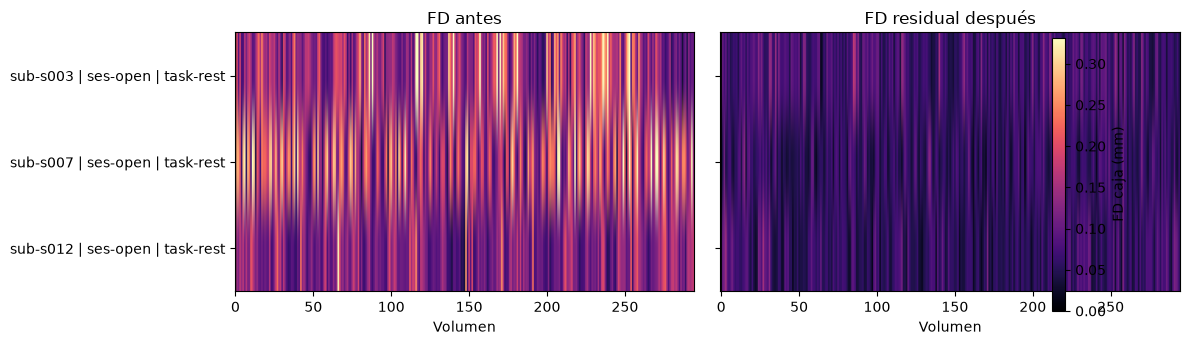

Dropdown(description='BOLD:', options=(('sub-s003 | ses-open | task-rest', 0), ('sub-s007 | ses-open | task-re…

Output()

In [ ]:
import importlib
import src.func_preproc as func

importlib.reload(func)

print("Algoritmo:", func.ALGORITMO_QC_MOVIMIENTO)

resultados_movimiento = func.estimar_movimiento_residual_lote(
    resultados_movimiento,
    overwrite=False,
    verbose=False,
)

resumen_qc_movimiento = func.mostrar_qc_movimiento(
    resultados_movimiento,
    umbral_fd=0.5,
    incluir_senal=False,
)

## 2.4 Slice Timing Correction 

In [15]:
print("Algoritmo:", func.ALGORITMO_SLICE_TIMING)

resultados_stc = func.corregir_slice_timing_lote(
    resultados_movimiento,
    inventario_bold,
    referencia="mitad_TR",
    orden_spline=3,
    overwrite=False,
)

display(
    resultados_stc[
        [
            "subject",
            "stc_status",
            "stc_seconds",
            "reference_time_s",
            "max_slice_shift_volumes",
            "stc_path",
        ]
    ]
)

Algoritmo: Interpolación spline cúbica por corte → referencia temporal TR/2
[1/3] sub-s003: slice timing
    procesado → sub-s003_ses-open_task-rest_desc-mocoStc_bold.nii.gz | desplazamiento máximo: 0.5 vol
[2/3] sub-s007: slice timing
    procesado → sub-s007_ses-open_task-rest_desc-mocoStc_bold.nii.gz | desplazamiento máximo: 0.5 vol
[3/3] sub-s012: slice timing
    procesado → sub-s012_ses-open_task-rest_desc-mocoStc_bold.nii.gz | desplazamiento máximo: 0.5 vol


,subject,stc_status,stc_seconds,reference_time_s,max_slice_shift_volumes,stc_path
0,s003,procesado,24.6,1.0,0.5,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...
1,s007,procesado,24.9,1.0,0.5,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...
2,s012,procesado,25.1,1.0,0.5,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...


In [16]:
func.mostrar_qc_slice_timing(resultados_stc)

Dropdown(description='BOLD:', options=(('sub-s003 | ses-open', 0), ('sub-s007 | ses-open', 1), ('sub-s012 | se…

Output()

## 2.5 Coregistro con T1

In [17]:
print("Algoritmo:", func.ALGORITMO_CORREGISTRO)

resultados_coregistro = func.coregistrar_bold_t1_lote(
    resultados_stc,
    resultados_segmentacion,
    overwrite=False,
    verbose=False,
)

display(
    resultados_coregistro[
        [
            "subject",
            "coreg_status",
            "coreg_seconds",
            "dice_epi_t1",
            "epi_inside_t1_pct",
            "t1_covered_by_epi_pct",
            "bold_native_path",
            "boldref_t1_path",
        ]
    ]
)

Algoritmo: ANTs Rigid con información mutua: BOLD medio → T1w BET
[1/3] sub-s003: BOLD → T1w
    procesado | Dice: 0.908 | EPI dentro del cerebro: 85.4%
[2/3] sub-s007: BOLD → T1w
    procesado | Dice: 0.925 | EPI dentro del cerebro: 90.1%
[3/3] sub-s012: BOLD → T1w
    procesado | Dice: 0.904 | EPI dentro del cerebro: 85.7%


,subject,coreg_status,coreg_seconds,dice_epi_t1,epi_inside_t1_pct,t1_covered_by_epi_pct,bold_native_path,boldref_t1_path
0,s003,procesado,12.7,0.908,85.4,96.9,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...
1,s007,procesado,9.8,0.925,90.1,95.1,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...
2,s012,procesado,11.5,0.904,85.7,95.8,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...


In [18]:
func.mostrar_qc_coregistro(resultados_coregistro)

Dropdown(description='Sujeto:', options=(('sub-s003 | ses-open', 0), ('sub-s007 | ses-open', 1), ('sub-s012 | …

Output()

## 2.6 Normalización

In [19]:
print("Algoritmo:", func.ALGORITMO_NORMALIZACION_BOLD)

resultados_bold_mni = func.normalizar_bold_mni_lote(
    resultados_coregistro,
    resultados_normalizacion,
    overwrite=False,
)

display(
    resultados_bold_mni[
        [
            "subject",
            "normalization_status",
            "normalization_seconds",
            "dice_epi_mni",
            "epi_inside_mni_pct",
            "mni_covered_by_epi_pct",
            "normalized_bold_path",
        ]
    ]
)

Algoritmo: ANTs: composición BOLD→T1w + T1w→MNI152 → una interpolación lineal
[1/3] sub-s003: BOLD → MNI152
        volumen 25/295
        volumen 50/295
        volumen 75/295
        volumen 100/295
        volumen 125/295
        volumen 150/295
        volumen 175/295
        volumen 200/295
        volumen 225/295
        volumen 250/295
        volumen 275/295
        volumen 295/295
    procesado | Dice: 0.919 | EPI dentro de MNI: 87.5%
[2/3] sub-s007: BOLD → MNI152
        volumen 25/295
        volumen 50/295
        volumen 75/295
        volumen 100/295
        volumen 125/295
        volumen 150/295
        volumen 175/295
        volumen 200/295
        volumen 225/295
        volumen 250/295
        volumen 275/295
        volumen 295/295
    procesado | Dice: 0.917 | EPI dentro de MNI: 88.1%
[3/3] sub-s012: BOLD → MNI152
        volumen 25/295
        volumen 50/295
        volumen 75/295
        volumen 100/295
        volumen 125/295
        volumen 150/295
        vol

,subject,normalization_status,normalization_seconds,dice_epi_mni,epi_inside_mni_pct,mni_covered_by_epi_pct,normalized_bold_path
0,s003,procesado,93.3,0.919,87.5,96.6,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...
1,s007,procesado,78.0,0.917,88.1,95.6,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...
2,s012,procesado,77.3,0.899,84.9,95.5,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...


In [20]:
func.mostrar_qc_normalizacion_bold(
    resultados_bold_mni
)

Dropdown(description='Sujeto:', options=(('sub-s003 | ses-open', 0), ('sub-s007 | ses-open', 1), ('sub-s012 | …

Output()

## 2.7 aCompCor

In [21]:
print("Algoritmo:", func.ALGORITMO_ACOMPCOR)

resultados_acompcor = func.extraer_acompcor_lote(
    resultados_bold_mni,
    resultados_segmentacion,
    resultados_normalizacion,
    n_components=5,
    probability_threshold=0.80,
    erosion_iterations=1,
    overwrite=False,
)

display(
    resultados_acompcor[
        [
            "subject",
            "acompcor_status",
            "acompcor_seconds",
            "wm_mask_voxels",
            "csf_mask_voxels",
            "wm_variance_first_n_pct",
            "csf_variance_first_n_pct",
            "acompcor_path",
        ]
    ]
)

Algoritmo: aCompCor: WM/CSF anatómicos en MNI152 → umbral + erosión → PCA temporal
[1/3] sub-s003: aCompCor
    procesado | WM: 48711 vóxeles | CSF: 3481 vóxeles
[2/3] sub-s007: aCompCor
    procesado | WM: 54112 vóxeles | CSF: 3122 vóxeles
[3/3] sub-s012: aCompCor
    procesado | WM: 49655 vóxeles | CSF: 2544 vóxeles


,subject,acompcor_status,acompcor_seconds,wm_mask_voxels,csf_mask_voxels,wm_variance_first_n_pct,csf_variance_first_n_pct,acompcor_path
0,s003,procesado,28.5,48711,3481,9.5,34.8,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...
1,s007,procesado,28.2,54112,3122,8.2,43.0,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...
2,s012,procesado,28.7,49655,2544,10.8,25.4,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...


In [22]:
func.mostrar_qc_acompcor(
    resultados_acompcor
)

Dropdown(description='Sujeto:', options=(('sub-s003 | ses-open', 0), ('sub-s007 | ses-open', 1), ('sub-s012 | …

Output()

## 2.8 Denoising

In [23]:
print("Algoritmo:", func.ALGORITMO_DENOISING)

resultados_denoising = func.aplicar_denoising_lote(
    resultados_acompcor,
    high_pass=0.008,
    low_pass=0.09,
    fd_threshold=0.5,
    gschange_threshold=3.0,
    n_acompcor=5,
    fast_mode=True,
    overwrite=True,
)

display(
    resultados_denoising[
        [
            "subject",
            "denoising_status",
            "denoising_seconds",
            "retained_volumes",
            "censored_volumes",
            "effective_dof",
            "corr_fd_dvars_before",
            "corr_fd_dvars_after",
            "denoised_path",
        ]
    ]
)

Algoritmo: 24HMP + 5 WM aCompCor + 5 CSF aCompCor + censurado → regresión y filtro 0.008–0.09 Hz simultáneos
[1/3] sub-s003: denoising
    1/4 Leyendo únicamente los vóxeles de la máscara...
    2/4 Filtrando BOLD y regresores en la misma banda...
    3/4 Regresando movimiento y aCompCor por bloques...
    4/4 Guardando resultados y métricas QC...
    procesado | retenidos: 288 | censurados: 7 | corr FD–DVARS: 0.249 → 0.040
[2/3] sub-s007: denoising
    1/4 Leyendo únicamente los vóxeles de la máscara...
    2/4 Filtrando BOLD y regresores en la misma banda...
    3/4 Regresando movimiento y aCompCor por bloques...
    4/4 Guardando resultados y métricas QC...
    procesado | retenidos: 285 | censurados: 10 | corr FD–DVARS: 0.060 → -0.053
[3/3] sub-s012: denoising
    1/4 Leyendo únicamente los vóxeles de la máscara...
    2/4 Filtrando BOLD y regresores en la misma banda...
    3/4 Regresando movimiento y aCompCor por bloques...
    4/4 Guardando resultados y métricas QC...
    proces

,subject,denoising_status,denoising_seconds,retained_volumes,censored_volumes,effective_dof,corr_fd_dvars_before,corr_fd_dvars_after,denoised_path
0,s003,procesado,17.0,288,7,83.0,0.249,0.040,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...
1,s007,procesado,16.5,285,10,82.7,0.060,-0.053,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...
2,s012,procesado,17.2,290,5,83.6,0.121,-0.157,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...


In [24]:
func.mostrar_qc_denoising(
    resultados_denoising
)

Dropdown(description='Sujeto:', options=(('sub-s003 | ses-open', 0), ('sub-s007 | ses-open', 1), ('sub-s012 | …

Output()

In [25]:
import importlib
import src.func_preproc as func

importlib.reload(func)

<module 'src.func_preproc' from '/Users/isabella/DOCTORADO/Worskshop-fMRI-preprocessing-basics/src/func_preproc.py'>

## 3. **Extracción de la señal BOLD - Schaefer 400** ૮ ˶ᵔ ᵕ ᵔ˶ ა

In [26]:
print("Algoritmo:", func.ALGORITMO_PARCELACION)

ATLAS_SCHAEFER = func.preparar_atlas_schaefer(
    atlas_root=PATHS["external"] / "atlases",
    template_path=MNI_TEMPLATE,
    n_rois=400,
    yeo_networks=17,
    resolution_mm=2,
)

print("Atlas:", ATLAS_SCHAEFER["name"])

resultados_roi, cobertura_roi = func.extraer_series_roi_lote(
    resultados_denoising,
    ATLAS_SCHAEFER,
    min_coverage=0.50,
    min_voxels=10,
    overwrite=False,
)

display(
    resultados_roi[
        [
            "subject",
            "roi_status",
            "roi_seconds",
            "valid_rois",
            "common_valid_rois",
            "mean_roi_coverage_pct",
            "roi_timeseries_path",
        ]
    ]
)

Algoritmo: Schaefer 2018 en MNI152 2 mm → promedio de los vóxeles cubiertos por cada región
Atlas: Schaefer400_17Networks_2mm
[1/3] sub-s003: series Schaefer
    procesado | regiones válidas: 400/400
[2/3] sub-s007: series Schaefer
    procesado | regiones válidas: 398/400
[3/3] sub-s012: series Schaefer
    procesado | regiones válidas: 400/400


,subject,roi_status,roi_seconds,valid_rois,common_valid_rois,mean_roi_coverage_pct,roi_timeseries_path
0,s003,procesado,0.2,400,398,98.8,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...
1,s007,procesado,0.2,398,398,98.6,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...
2,s012,procesado,0.2,400,398,99.1,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...


In [27]:
func.mostrar_qc_series_roi(
    resultados_roi,
    cobertura_roi,
    ATLAS_SCHAEFER,
)

Dropdown(description='Sujeto:', options=(('sub-s003 | ses-open', 0), ('sub-s007 | ses-open', 1), ('sub-s012 | …

Output()

In [28]:
display(
    resultados_roi[
        [
            "subject",
            "valid_rois",
            "common_valid_rois",
            "mean_roi_coverage_pct",
        ]
    ]
)

,subject,valid_rois,common_valid_rois,mean_roi_coverage_pct
0,s003,400,398,98.8
1,s007,398,398,98.6
2,s012,400,398,99.1


In [29]:
rois_excluidas = (
    cobertura_roi.loc[
        ~cobertura_roi["common_valid"],
        [
            "subject",
            "roi_id",
            "label",
            "network",
            "coverage_pct",
            "valid",
        ],
    ]
    .sort_values(["roi_id", "subject"])
)

display(rois_excluidas)

,subject,roi_id,label,network,coverage_pct,valid
114,s003,115,17Networks_LH_LimbicA_TempPole_2,LimbicA,66.4,True
514,s007,115,17Networks_LH_LimbicA_TempPole_2,LimbicA,46.1,False
914,s012,115,17Networks_LH_LimbicA_TempPole_2,LimbicA,61.7,True
116,s003,117,17Networks_LH_LimbicA_TempPole_4,LimbicA,62.6,True
516,s007,117,17Networks_LH_LimbicA_TempPole_4,LimbicA,40.6,False
916,s012,117,17Networks_LH_LimbicA_TempPole_4,LimbicA,75.7,True


## 4. **Conectividad funcional** ૮ • ﻌ - ა

In [30]:

print("Algoritmo:", func.ALGORITMO_CONECTIVIDAD)

resultados_conectividad = func.calcular_conectividad_lote(
    resultados_roi,
    cobertura_roi,
    ATLAS_SCHAEFER,
    overwrite=False,
)

display(
    resultados_conectividad[
        [
            "subject",
            "connectivity_status",
            "connectivity_rois",
            "mean_absolute_r",
            "connectivity_qc_valid",
            "connectivity_path",
        ]
    ]
)

Algoritmo: Correlación de Pearson entre las series Schaefer de las ROIs válidas en todos los sujetos
[1/3] sub-s003: conectividad
    procesado | 398 ROIs | QC: OK
[2/3] sub-s007: conectividad
    procesado | 398 ROIs | QC: OK
[3/3] sub-s012: conectividad
    procesado | 398 ROIs | QC: OK


,subject,connectivity_status,connectivity_rois,mean_absolute_r,connectivity_qc_valid,connectivity_path
0,s003,procesado,398,0.158,True,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...
1,s007,procesado,398,0.186,True,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...
2,s012,procesado,398,0.128,True,/Users/isabella/DOCTORADO/Worskshop-fMRI-prepr...


In [31]:
func.mostrar_qc_conectividad(
    resultados_conectividad,
    ATLAS_SCHAEFER,
)

Dropdown(description='Sujeto:', options=(('sub-s003 | ses-open', 0), ('sub-s007 | ses-open', 1), ('sub-s012 | …

Output()

# **¡Gracias!**

# ฅ^>⩊<^ ฅ